# 2. Model Pipeline with Cross-Validation

## Objetivo
Construir un flujo seguro de entrenamiento usando `Pipeline` y `GridSearchCV`, evitando fuga de datos y trabajando correctamente con variables numéricas y categóricas del dataset `heart.csv`.

## Idea del notebook
1. Cargar el dataset.
2. Separar variables predictoras y variable objetivo.
3. Identificar columnas numéricas y categóricas.
4. Construir un preprocesamiento con `ColumnTransformer`.
5. Entrenar varios modelos dentro de un `Pipeline`.
6. Ajustar hiperparámetros con `GridSearchCV`.
7. Comparar los modelos con AUC.
8. Seleccionar y exportar el mejor modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("../heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (918, 12)

Tipos de datos:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Valores nulos por columna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [4]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"].copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nDistribución de la variable objetivo:")
print(y.value_counts())
print("\nProporciones:")
print(y.value_counts(normalize=True))

Forma de X: (918, 11)
Forma de y: (918,)

Distribución de la variable objetivo:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Proporciones:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Variables categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## Separación de entrenamiento y prueba

Primero dividimos el dataset en entrenamiento y prueba.  
Esto es importante para evitar que el preprocesamiento use información del conjunto de prueba antes de tiempo.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (734, 11)
X_test: (184, 11)
y_train: (734,)
y_test: (184,)


## Preprocesamiento con ColumnTransformer

- Variables numéricas:
  - imputación con mediana
  - escalado con `StandardScaler`

- Variables categóricas:
  - imputación con moda
  - codificación con `OneHotEncoder`

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Definición de modelos y grids de búsqueda

Vamos a comparar cuatro modelos:
- Logistic Regression
- KNN
- Random Forest
- SVC

In [8]:
models_and_parameters = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    },
    "SVC": {
        "model": SVC(probability=True),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1, 1]
        }
    }
}

## Entrenamiento con Pipeline + GridSearchCV

Cada modelo se entrena dentro de un pipeline completo:
- preprocesamiento
- modelo

Esto garantiza que el preprocesamiento se ajuste únicamente con los datos de entrenamiento en cada pliegue de validación cruzada.

In [9]:
results = []
best_estimators = {}

for model_name, config in models_and_parameters.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config["params"],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)
    
    test_auc = roc_auc_score(y_test, y_proba)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        "Modelo": model_name,
        "Mejor CV AUC": round(grid.best_score_, 4),
        "Test AUC": round(test_auc, 4),
        "Test Accuracy": round(test_accuracy, 4),
        "Mejores parámetros": grid.best_params_
    })
    
    best_estimators[model_name] = best_model
    
    print(f"Modelo: {model_name}")
    print(f"Mejor CV AUC: {grid.best_score_:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Mejores parámetros: {grid.best_params_}")
    print("-" * 60)

Modelo: LogisticRegression
Mejor CV AUC: 0.9226
Test AUC: 0.9323
Test Accuracy: 0.8913
Mejores parámetros: {'model__C': 0.1}
------------------------------------------------------------
Modelo: KNN
Mejor CV AUC: 0.9141
Test AUC: 0.9534
Test Accuracy: 0.9239
Mejores parámetros: {'model__n_neighbors': 9, 'model__weights': 'distance'}
------------------------------------------------------------
Modelo: RandomForest
Mejor CV AUC: 0.9288
Test AUC: 0.9362
Test Accuracy: 0.8967
Mejores parámetros: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
------------------------------------------------------------
Modelo: SVC
Mejor CV AUC: 0.9245
Test AUC: 0.9497
Test Accuracy: 0.8913
Mejores parámetros: {'model__C': 1, 'model__gamma': 0.1}
------------------------------------------------------------


In [10]:
results_df = pd.DataFrame(results).sort_values(by="Test AUC", ascending=False).reset_index(drop=True)
results_df

,Modelo,Mejor CV AUC,Test AUC,Test Accuracy,Mejores parámetros
0,KNN,0.9141,0.9534,0.9239,"{'model__n_neighbors': 9, 'model__weights': 'd..."
1,SVC,0.9245,0.9497,0.8913,"{'model__C': 1, 'model__gamma': 0.1}"
2,RandomForest,0.9288,0.9362,0.8967,"{'model__max_depth': 5, 'model__min_samples_sp..."
3,LogisticRegression,0.9226,0.9323,0.8913,{'model__C': 0.1}


In [11]:
best_model_name = results_df.loc[0, "Modelo"]
best_model = best_estimators[best_model_name]

print("Mejor modelo seleccionado:", best_model_name)

Mejor modelo seleccionado: KNN


In [12]:
joblib.dump(best_model, "../model.joblib")
print("Modelo exportado correctamente a ../model.joblib")

Modelo exportado correctamente a ../model.joblib


In [13]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

best_auc = roc_auc_score(y_test, y_proba_best)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_cm = confusion_matrix(y_test, y_pred_best)

print("Modelo final:", best_model_name)
print("AUC final:", round(best_auc, 4))
print("Accuracy final:", round(best_accuracy, 4))
print("\nMatriz de confusión:")
print(best_cm)
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))

Modelo final: KNN
AUC final: 0.9534
Accuracy final: 0.9239

Matriz de confusión:
[[75  7]
 [ 7 95]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        82
           1       0.93      0.93      0.93       102

    accuracy                           0.92       184
   macro avg       0.92      0.92      0.92       184
weighted avg       0.92      0.92      0.92       184



In [14]:
cm_df = pd.DataFrame(
    best_cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)
cm_df

,Pred 0,Pred 1
Real 0,75,7
Real 1,7,95


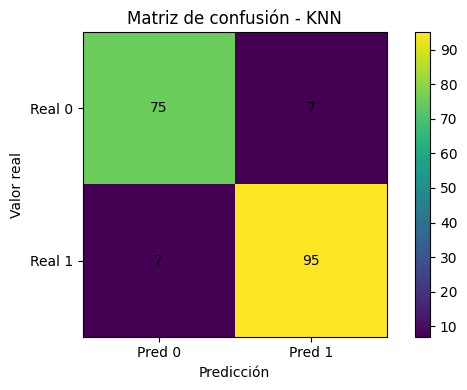

In [15]:
plt.figure(figsize=(6, 4))
plt.imshow(best_cm, interpolation="nearest")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
plt.yticks(tick_marks, ["Real 0", "Real 1"])

for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        plt.text(j, i, str(best_cm[i, j]), ha="center", va="center")

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

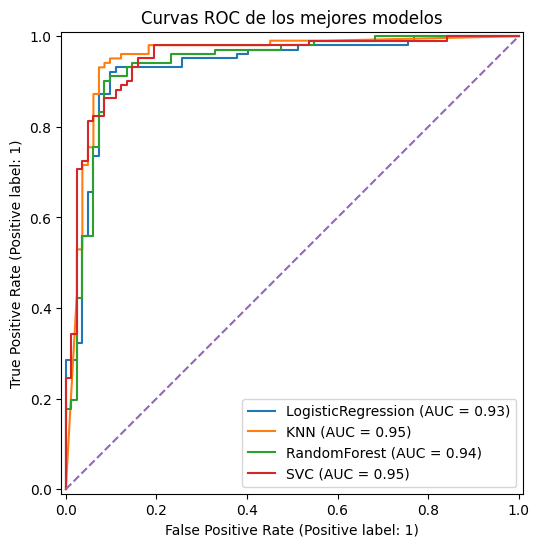

In [16]:
plt.figure(figsize=(8, 6))

for model_name, estimator in best_estimators.items():
    RocCurveDisplay.from_estimator(estimator, X_test, y_test, name=model_name, ax=plt.gca())

plt.title("Curvas ROC de los mejores modelos")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

## Conclusión

En este notebook se construyó un flujo seguro de entrenamiento usando `Pipeline` y `GridSearchCV`.

### Resultados logrados
- Se evitó la fuga de datos durante el preprocesamiento.
- Se trabajó correctamente con variables numéricas y categóricas.
- Se compararon varios modelos de clasificación.
- Se seleccionó el mejor modelo según el desempeño en el conjunto de prueba.
- Se exportó el modelo final a `model.joblib`.

Este notebook deja listo el modelo para la siguiente etapa del proyecto: servir predicciones mediante FastAPI.